# Assignment

Complete the three exercises below. Run each code cell and include your outputs/interpretation for submission.

## Part 1: Probability and Expected Value

Tasks:

- Simulate 10,000 trials of flipping 3 coins
- Plot empirical probability for 0, 1, 2, 3 heads
- Compute expected value from simulation
- Compare with theoretical probabilities

First 10 simulated outcomes (number of heads in 3 flips): [1 1 1 1 1 3 1 2 2 1]
Empirical probabilities for outcomes 0, 1, 2, 3 heads: [0.1189 0.3735 0.3817 0.1259]
Empirical expected value: 1.5146
Theoretical expected value: 1.5000
   heads  empirical_prob  theoretical_prob  abs_diff
0      0          0.1189             0.125    0.0061
1      1          0.3735             0.375    0.0015
2      2          0.3817             0.375    0.0067
3      3          0.1259             0.125    0.0009


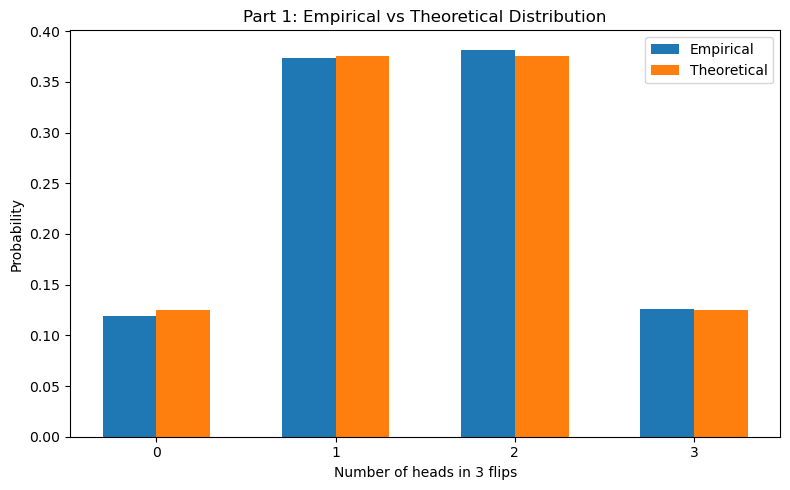

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducibility 
np.random.seed(50)  # Fixes the random number sequence so results are repeatable each run

# Simulate: number of heads in 3 coin flips over 10,000 trials
n_trials = 10_000
"""
Yes, 10_000 denotes the integer 10000 in Python.

It is a numeric literal, not text.
The underscore is just for readability in large numbers.
So these are equivalent: 10_000 == 10000 → True.
If it were text, it would need quotes, like "10_000", which is a string.
"""

heads = np.random.binomial(n=3, p=0.5, size=n_trials)
print(f"First 10 simulated outcomes (number of heads in 3 flips): {heads[:10]}")

# Empirical probability distribution
outcomes = np.array([0, 1, 2, 3])
counts = np.array([(heads == k).sum() for k in outcomes])
empirical_probs = counts / n_trials
print(f"Empirical probabilities for outcomes 0, 1, 2, 3 heads: {empirical_probs}")

# Theoretical Binomial(3, 0.5) probabilities
theoretical_probs = np.array([1, 3, 3, 1]) / 8  
# Coefficients from (a+b)^3: C(3,k) = [1,3,3,1], and divide by 2^3=8 equally likely outcomes

""" 
Why 1, 3, 3, 1:

These are binomial coefficients, (C(3,k)) for (k=0,1,2,3).
They count how many ways each number of heads can happen:
0 heads: 1 way (TTT)
1 head: 3 ways (HTT, THT, TTH)
2 heads: 3 ways (HHT, HTH, THH)
3 heads: 1 way (HHH) 
"""

# Expected value (empirical and theoretical)
empirical_ev = heads.mean()
theoretical_ev = 3 * 0.5

print(f"Empirical expected value: {empirical_ev:.4f}")
print(f"Theoretical expected value: {theoretical_ev:.4f}")

comparison = pd.DataFrame({
    "heads": outcomes,
    "empirical_prob": empirical_probs,
    "theoretical_prob": theoretical_probs,
    "abs_diff": np.abs(empirical_probs - theoretical_probs)
})
print(comparison)

# Plot
plt.figure(figsize=(8, 5))
plt.bar(outcomes - 0.15, empirical_probs, width=0.3, label="Empirical")
plt.bar(outcomes + 0.15, theoretical_probs, width=0.3, label="Theoretical")
plt.xticks(outcomes)
plt.xlabel("Number of heads in 3 flips")
plt.ylabel("Probability")
plt.title("Part 1: Empirical vs Theoretical Distribution")
plt.legend()
plt.tight_layout()
plt.show()

## Part 2: Normal Distribution and Statistical Testing

Tasks:

- Generate Sample A (mean=70, std=5, n=100) and Sample B (mean=73, std=5, n=100)
- Draw a box plot comparison
- Run an independent two-sample t-test
- Compute and visualize 95% confidence intervals

Sample A - mean: 69.48, std: 4.54
Sample B - mean: 73.11, std: 4.77


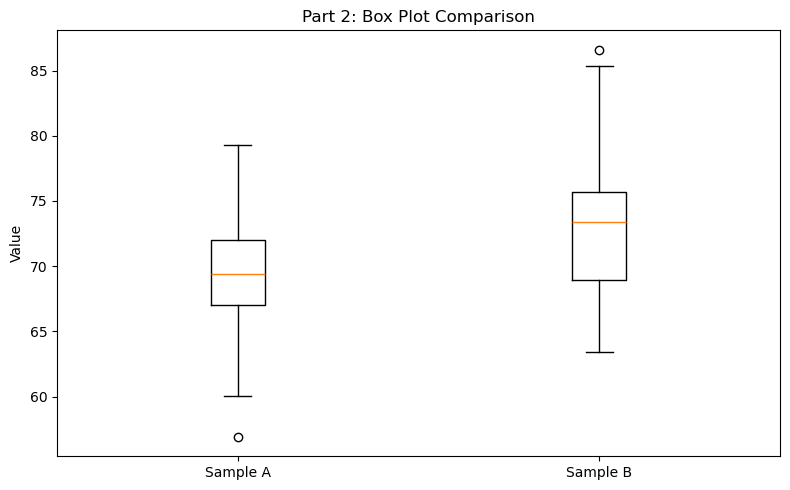

t-statistic: -5.5140
p-value: 0.000000
  sample       mean     ci_low    ci_high
0      A  69.480767  68.579766  70.381769
1      B  73.111523  72.165380  74.057666


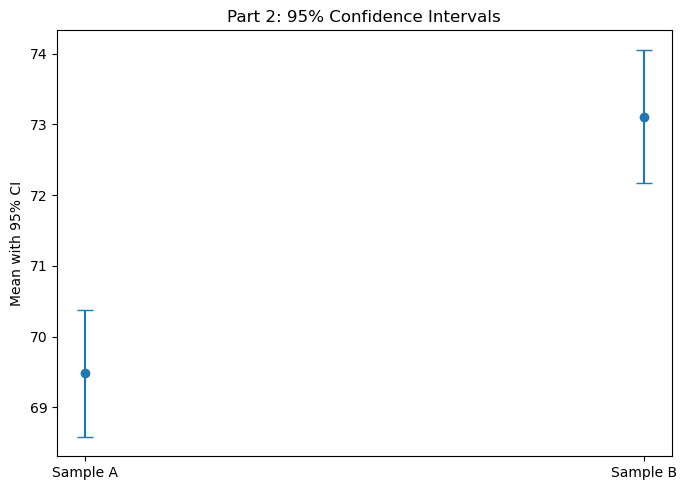

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

# Generate samples
n = 100
sample_a = np.random.normal(loc=70, scale=5, size=n)
sample_b = np.random.normal(loc=73, scale=5, size=n)
print(f"Sample A - mean: {sample_a.mean():.2f}, std: {sample_a.std(ddof=1):.2f}")
print(f"Sample B - mean: {sample_b.mean():.2f}, std: {sample_b.std(ddof=1):.2f}")

# Box plot comparison
plt.figure(figsize=(8, 5))
plt.boxplot([sample_a, sample_b], labels=["Sample A", "Sample B"])
plt.ylabel("Value")
plt.title("Part 2: Box Plot Comparison")
plt.tight_layout()
plt.show()

# Independent two-sample t-test (Welch's t-test) - Refer to note below
t_stat, p_value = stats.ttest_ind(sample_a, sample_b, equal_var=False)
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.6f}")

# 95% confidence intervals for each sample mean
def mean_ci_95(x):
    x = np.asarray(x)
    mean = x.mean()
    sem = stats.sem(x)
    margin = stats.t.ppf(0.975, df=len(x)-1) * sem
    return mean, mean - margin, mean + margin

mean_a, low_a, high_a = mean_ci_95(sample_a)
mean_b, low_b, high_b = mean_ci_95(sample_b)

ci_df = pd.DataFrame({
    "sample": ["A", "B"],
    "mean": [mean_a, mean_b],
    "ci_low": [low_a, low_b],
    "ci_high": [high_a, high_b]
})
print(ci_df)

# CI visualization
plt.figure(figsize=(7, 5))
xpos = np.arange(len(ci_df))
means = ci_df["mean"].values
yerr = np.vstack([means - ci_df["ci_low"].values, ci_df["ci_high"].values - means])
plt.errorbar(xpos, means, yerr=yerr, fmt="o", capsize=6)
plt.xticks(xpos, ["Sample A", "Sample B"])
plt.ylabel("Mean with 95% CI")
plt.title("Part 2: 95% Confidence Intervals")
plt.tight_layout()
plt.show()

## Independent Two-Sample t-Test

```python
t_stat, p_value = stats.ttest_ind(sample_a, sample_b, equal_var=False)
```

This compares the **means of two groups** to decide if their difference is real or just random chance.

**`equal_var=False`** triggers Welch's t-test, which is the safer default -- it works even when the two groups have different spreads (variances).

---

**What the two outputs mean:**

| Output | What it tells you |
|---|---|
| `t_stat` | How far apart the means are, measured in units of variability. Larger absolute value = bigger gap. Negative means sample_a mean is lower; positive means it's higher. |
| `p_value` | If the null hypothesis (no real difference) were true, how likely is it to see a gap this large just by chance? |

**Reading the p-value:**
- `p < 0.05` -- the difference is statistically significant; unlikely to be random noise
- `p >= 0.05` -- the difference could plausibly be due to chance; not enough evidence to reject the null

---

**Null hypothesis here:** "The two population means are equal."

A small p-value is evidence against that -- meaning the groups are likely genuinely different.

**t-statistic: -5.5140**
sample_a's mean is lower than sample_b's mean, and the gap is 5.51 standard errors wide -- that's a large difference.

**p-value: ~0.000000**
Essentially zero. The probability of seeing a difference this large by random chance (assuming no real difference) is negligible.

---

**Conclusion:** Reject the null hypothesis. The two group means are statistically significantly different. The result is not due to random sampling variation.

## Part 3: Correlation Analysis (Iris Dataset)

Tasks:

- Analyze Sepal length vs Petal length
- Analyze Sepal width vs Petal width
- For each pair: scatter plot, Pearson r and p-value, R-squared
- Decide which pair is stronger and explain briefly

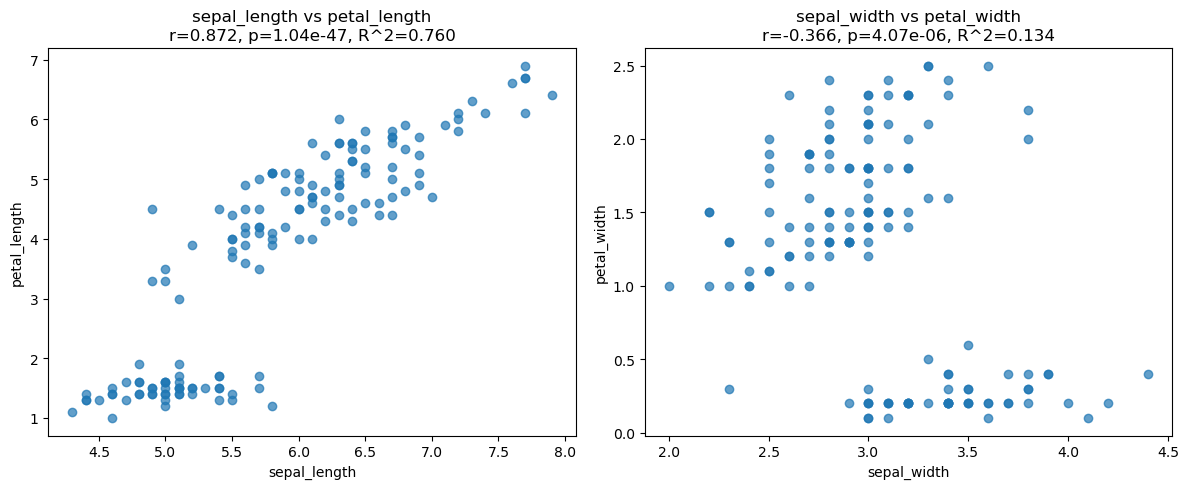

sepal_length vs petal_length: r=0.8718, p-value=1.038667e-47, R^2=0.7600
sepal_width vs petal_width: r=-0.3661, p-value=4.073229e-06, R^2=0.1340

Stronger relationship:
sepal_length vs petal_length (R^2=0.7600)


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

iris = sns.load_dataset("iris")

pairs = [
    ("sepal_length", "petal_length"),
    ("sepal_width", "petal_width"),
]

results = []

plt.figure(figsize=(12, 5))
for i, (x_col, y_col) in enumerate(pairs, start=1):
    x = iris[x_col].values
    y = iris[y_col].values

    r, p = stats.pearsonr(x, y)
    r2 = r ** 2
    results.append((x_col, y_col, r, p, r2))

    ax = plt.subplot(1, 2, i)
    ax.scatter(x, y, alpha=0.7)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f"{x_col} vs {y_col}\nr={r:.3f}, p={p:.2e}, R^2={r2:.3f}")

plt.tight_layout()
plt.show()

for x_col, y_col, r, p, r2 in results:
    print(f"{x_col} vs {y_col}: r={r:.4f}, p-value={p:.6e}, R^2={r2:.4f}")

# Determine stronger linear relationship by larger R^2
stronger = max(results, key=lambda row: row[4])
print("\nStronger relationship:")
print(f"{stronger[0]} vs {stronger[1]} (R^2={stronger[4]:.4f})")

**Sepal length vs petal length** is the stronger relationship.

The stats confirm it clearly:

| Metric | Sepal L vs Petal L | Sepal W vs Petal W |
|---|---|---|
| r | 0.872 | -0.366 |
| R^2 | 0.760 | 0.134 |
| p-value | 1.04e-47 | 4.07e-06 |

**Why it's stronger:**

- r = 0.872 indicates a strong positive linear correlation. As sepal length increases, petal length increases consistently.
- R^2 = 0.760 means sepal length explains 76% of the variance in petal length. That's substantial predictive power.
- The scatter plot shows points clustering tightly along a diagonal trend, with two visible groups (likely two species) both following the same direction.

**Why the right plot is weak:**

- r = -0.366 is a weak negative correlation. The negative sign means wider sepals tend to have slightly narrower petals, but the relationship is unreliable.
- R^2 = 0.134 means sepal width explains only 13.4% of petal width variance. The remaining 86.6% is noise or other factors.
- The scatter plot shows a diffuse cloud with no clear trend.

Both p-values are statistically significant (well below 0.05), but statistical significance alone does not mean practical strength. The left plot wins on effect size.

You can infer it visually from the plot alone.

**What to look for:**

- **Tightness of the scatter** -- In the left plot, points cluster closely along a clear upward diagonal. In the right plot, points are spread loosely with no obvious direction.

- **Direction of trend** -- The left plot shows a consistent positive slope. The right plot has no clear slope visible.

- **Spread around the trend line** -- Less vertical scatter around the line = stronger relationship. The left plot has noticeably less scatter relative to its trend than the right.

**The limitation of visual inference:**

You can confidently say "left is stronger" from the plot, but you cannot quantify how much stronger without the correlation coefficient. For example, you cannot tell from the plot alone whether r is 0.87 or 0.95 -- you need the stats for that precision.

So: visual inspection is sufficient for a directional judgment, not a precise one.

## Submission Notes

- Add a short interpretation below each part.
- For Part 2, state whether the p-value is below 0.05.
- For Part 3, explain why the pair with larger R-squared is stronger.
- Commit and push this notebook, then submit the repository URL.